### Figure 4

This code generates Figure 4 of the paper. This figure compares mRNA expression correlation between TF-target genes for biologically relevant binding targets and spurious targets <br>
<br>
INPUT:<br>
processed/ExpDecayConst_params.csv : Parameters for two-state model for each dataset<br>
processed/Compiled_accessible_target_ChIP_peaks.csv: Cumulative positional distribution of<br>
TF binding events
<br>
<br>
OUTPUT: <br>
Figure4.pdf <br>





In [1]:
#Load require
import os 
import pandas as pd
import numpy as np
from plotnine import *
import matplotlib.pyplot as plt
from scipy.stats import linregress, spearmanr, fisher_exact,pearsonr
from scipy.optimize import curve_fit
from math import exp,log
from scipy.stats import norm
from utils import *
import patchworklib as pw
from random import choices
from sklearn.linear_model import LinearRegression
import math
from sklearn.metrics import *
from statannot import add_stat_annotation
import seaborn as sns
font_size = 30
point_size = 5

sns.set_context("paper", rc={"font.size":font_size,"axes.titlesize":font_size,"axes.labelsize":font_size, 
                             "axes.ticklabelsize":font_size})   

labels = ['Spurious', 'Biologically \nRelevant']

def any_not_all(x):
    return (any(x) & (not all(x)))


#Set working directory
working_dir ="TF_Positional_Distribution_Model/data/ENCODE"
os.chdir(working_dir)

<Figure size 72x72 with 0 Axes>

In [2]:
#Load compiled peak distribution and parameters for each fit
params= pd.read_csv('processed/ExpDecayConst_params.csv', index_col =0)
df= pd.read_csv('processed/Compiled_accessible_target_ChIP_peaks.csv', index_col =0)

#Merge parameters for each cell line
df = df.merge(params,on=['TF','CellLine'])

#Reference annotation file
TSS_ref = pd.read_table('TF_TSS_10kb_named.bed')
TSS_ref['TSS'] = TSS_ref['end']-10000

## Load RNA-seq data for TF-target genes

In [3]:
compiled_correlation = pd.DataFrame()
for ids,row in params.loc[params.CellLine == 'K562'].iterrows():
    file = row['CellLine'] +'/ChIP-seq/' + row['TF'] + '_consensus_accessible_peaks_named.bed'
    
    #Load file for TF in cell line
    df =  pd.read_table(file,
                        names = ['chrom','start','end','Gene'])
    df =  df[['chrom','start','end','Gene']]
    df = df.drop_duplicates()
    
    #Get distance of peak from TSS
    df=df.merge(TSS_ref[['TSS','Gene']])
    df['start_diff'] =  df['start'] - df['TSS']
    df['end_diff'] =  df['end'] - df['TSS']
    df['min_dist'] = df.apply(lambda x: abs(sum([x['start_diff'], x['end_diff']])/2), axis =1)
    df = df.loc[df.min_dist <=10000]        
    
    #Calculate threshold within which true binding to spurious binding ratio is 10. 
    t = n_max_true(row.rb,row.tau,row.rs, [0.1]).Distance

    df['Threshold'] = df.min_dist <= t.values[0]



    #Obtain RNA-seq data
    genes = df.groupby('Gene')['Threshold'].apply(any).reset_index(name ='Threshold')
    rnaseq = pd.read_csv('RNA-seq/Compiled_RNAseq.csv',index_col =0)
    rnaseq.index = rnaseq.Gene
    rnaseq= rnaseq.drop('Gene', axis =1).T
    genes = genes.loc[genes.Gene.isin(rnaseq.columns)]
    corr = [list(spearmanr(rnaseq[row['TF']],rnaseq[i])) + 
            [genes.Threshold.iloc[idx], i,row['TF'], row['CellLine']] for idx,i in enumerate(genes.Gene)]
    corr =pd.DataFrame(corr, columns = ['Correlation','pval', 'Threshold', 'Gene', 'TF','CellLine'])
    compiled_correlation = pd.concat([compiled_correlation, corr])

#Classify genes as biologically relevant and spurious targets
compiled_correlation['Correlation_thresh'] = (abs(compiled_correlation['Correlation']) > 0.5) & (compiled_correlation['pval'] < 0.05) 
fill = compiled_correlation.groupby(['TF','Threshold']).apply(lambda x : x['Correlation_thresh'].sum()/len(x['Correlation_thresh']) ).reset_index()
fill.columns = ['TF','Threshold','Fraction']
fill['Threshold'] = [ labels[1] if i else labels[0] for i in fill['Threshold'] ]
compiled_correlation['Threshold'] = [ labels[1] if i else labels[0]  for i in compiled_correlation['Threshold'] ]
compiled_correlation['corr_abs'] = abs(compiled_correlation.Correlation)




## Plot Figure 4A and 4B

In [4]:

my_pal = {labels[1]: "g", labels[0]:"m"}
fig4B = pw.Brick(figsize=(6,4))
#sns.boxplot(data=compiled_correlation
#            ,x='Threshold', y = "corr_abs", ax = fig4B, palette = my_pal)
sns.violinplot(data=compiled_correlation
            ,x='Threshold', y = "corr_abs",ax = fig4B,  palette = my_pal)
fig4B.set(
    xlabel='\n', 
    ylabel="|Spearman's Rho|"
)
fig4B.tick_params(labelsize=26)
fig4B.axhline(y=0.5,color='black', linestyle='--')
fig4B, test_results = add_stat_annotation(fig4B,data=compiled_correlation,x='Threshold', y = "corr_abs" ,
                                   box_pairs=[(labels[0], labels[1])],
                                   line_offset_to_box=0.1, line_offset=0, 
                                    fontsize=16,line_height=0.008, text_offset=2,
                                   test='t-test_ind', text_format='star', loc='inside', verbose=2)

p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

Spurious v.s. Biologically 
Relevant: t-test independent samples with Bonferroni correction, P_val=0.000e+00 stat=-2.058e+02


<Figure size 432x288 with 0 Axes>

In [5]:
fig4A = pw.Brick(figsize=(6,4))
sns.boxplot(data=fill,x='Threshold', y = "Fraction",ax=fig4A, palette = my_pal)

fig4A.set(
    xlabel='\n', 
    ylabel='Fraction of edges \n'
)
fig4A.tick_params(labelsize=26)
fig4A, test_results = add_stat_annotation(fig4A,data=fill,x='Threshold', y = "Fraction" ,
                                   box_pairs=[(labels[0], labels[1])],
                                   line_offset_to_box=0.1, line_offset=0, 
                                    fontsize=16,line_height=0.008, text_offset=2,
                                   test='t-test_paired', text_format='star', loc='inside', verbose=2)

p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

Spurious v.s. Biologically 
Relevant: t-test paired samples with Bonferroni correction, P_val=1.752e-11 stat=-1.929e+01


<Figure size 432x288 with 0 Axes>

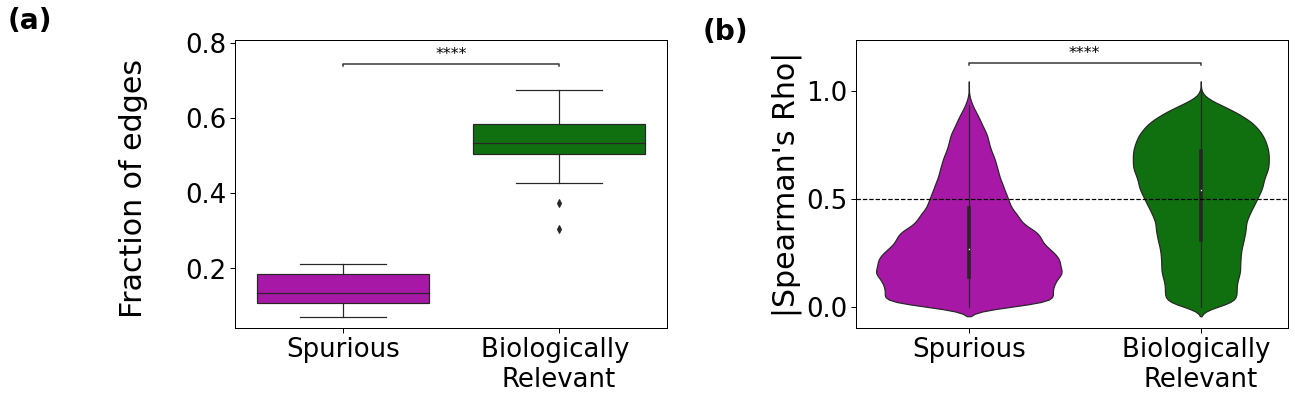

In [6]:
fig4A.set_index('(a)',size = 28,fontweight="bold")
fig4B.set_index('(b)',size = 28,fontweight="bold")


fig4 = (fig4A + fig4B)
fig4.savefig('../../Figures/Figure4.pdf')